# Tabular LIME - Theory 

In [ ]:
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename):
    return OUT_DIR / filename


## Interpretable Coefficent Cancellation

In [ ]:
# -*- coding: utf-8 -*-
"""

@author: dgarreau

For certain choices of hyperparameters, the interpretable coefficients can
vanish, thus effectively disappearing from the explanation. We demonstrate
this effect for a linear function with uniform training data. Changing the
number of bins from 4 (the default) to 5 puts nearly all interpretable coefficients
to 0, both in theory and in practice. This is Figure 9 in the paper.

"""

import numpy as np
import pandas as pd
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

from utils.aux_functions import get_training_data_stats
from utils.aux_functions import format_coefs
from theory.linear import compute_beta_linear

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai_book.plotting import BLUE as bookBlue, CHAPTER_GRAY as chaptergray, ORANGE as bookOrange, apply_notebook_style

apply_notebook_style(figsize=(16.0, 9.0), grid_axis="y")

n_exp = 100
n_samples = 5000
np.random.seed(1)
dim = 10
f = np.random.uniform(0, 10, (dim + 1,))

def my_model(array):
    return f[0] + np.dot(array, f[1:])

xi = np.zeros((dim,))
n_train = 1000
train = np.random.uniform(-10, 10, (n_train, dim))

for p in [4, 5]:
    print(f'Number of bins: {p}')

    my_stats = get_training_data_stats(train, p)
    explainer = lime.lime_tabular.LimeTabularExplainer(
        train,
        mode='regression',
        feature_selection='none',
        training_data_stats=my_stats,
    )

    beta_emp_store = np.zeros((n_exp, dim + 1))
    for i_exp in range(n_exp):
        if np.mod(i_exp + 1, 10) == 0:
            print(f'Experiment {i_exp + 1} / {n_exp} is running...')

        exp = explainer.explain_instance(xi, my_model, num_samples=n_samples)
        beta_emp_store[i_exp, :] = format_coefs(exp)

    default_nu = np.sqrt(0.75 * dim)
    beta_theo = compute_beta_linear(xi, f, default_nu, my_stats)

    columns = [f'$\beta_{i}$' for i in range(dim + 1)]
    df_results = pd.DataFrame(beta_emp_store, columns=columns)

    fig, ax = plt.subplots(figsize=(15, 10))
    sns.boxplot(
        data=df_results,
        ax=ax,
        color=bookBlue,
        whiskerprops={'color': bookBlue, 'alpha': 0.7},
        capprops={'color': bookBlue, 'alpha': 0.7},
        boxprops={'edgecolor': bookBlue, 'facecolor': (0.10, 0.45, 0.91, 0.25)},
        medianprops={'color': chaptergray},
    )

    ax.scatter(
        x=df_results.columns,
        y=beta_theo,
        color=bookOrange,
        s=150,
        zorder=10,
        marker='_',
        linewidths=3,
        label='Theoretical Value',
    )

    ax.set_title(f'Coefficients of Surrogate Model, $p={p}$', fontsize=20)
    ax.set_ylabel('Coefficient Value', fontsize=14)
    ax.set_xlabel('Coefficient', fontsize=14)
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.legend(fontsize=14)
    ax.axhline(0, ls='--', color=chaptergray, zorder=-1)

    plt.tight_layout()

    output_path = out_path(f'cancellation_{p}_boxes_sns.pdf')
    fig.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)
    print(f'Figure saved to {output_path}\n')

    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
# JUPYTER NOTEBOOK VERSION (Book-Ready Publication Figure)

import numpy as np
import pandas as pd
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from matplotlib.lines import Line2D

from utils.aux_functions import get_training_data_stats
from utils.aux_functions import format_coefs
from theory.linear import compute_beta_linear

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai_book.plotting import BLUE as bookBlue, CHAPTER_GRAY as chaptergray, ORANGE as bookOrange, apply_notebook_style

apply_notebook_style(figsize=(16.0, 9.0), grid_axis="y")

n_exp = 100
n_samples = 5000
np.random.seed(1)
dim = 10
f = np.random.uniform(0, 10, (dim + 1,))

def my_model(array):
    return f[0] + np.dot(array, f[1:])

xi = np.zeros((dim,))
n_train = 1000
train = np.random.uniform(-10, 10, (n_train, dim))

for p in [4, 5]:
    print(f'Number of bins: {p}')

    my_stats = get_training_data_stats(train, p)
    explainer = lime.lime_tabular.LimeTabularExplainer(
        train,
        mode='regression',
        feature_selection='none',
        training_data_stats=my_stats,
    )
    beta_emp_store = np.zeros((n_exp, dim + 1))
    for i_exp in range(n_exp):
        if np.mod(i_exp + 1, 10) == 0:
            print(f'Experiment {i_exp + 1} / {n_exp} is running...')
        exp = explainer.explain_instance(xi, my_model, num_samples=n_samples)
        beta_emp_store[i_exp, :] = format_coefs(exp)
    default_nu = np.sqrt(0.75 * dim)
    beta_theo = compute_beta_linear(xi, f, default_nu, my_stats)

    columns = [f'$\beta_{i}$' for i in range(dim + 1)]
    df_results = pd.DataFrame(beta_emp_store, columns=columns)
    df_long = df_results.melt(var_name='Coefficient', value_name='Value')

    fig, ax = plt.subplots(figsize=(16, 9))
    ax.axhline(0, linestyle='--', color=chaptergray, alpha=0.6, zorder=1)

    sns.stripplot(
        data=df_long,
        x='Coefficient',
        y='Value',
        ax=ax,
        jitter=0.3,
        size=3,
        color=chaptergray,
        alpha=0.45,
        zorder=3,
    )

    sns.violinplot(
        data=df_long,
        x='Coefficient',
        y='Value',
        ax=ax,
        color=bookBlue,
        inner=None,
        cut=0,
        linewidth=0,
        zorder=2,
    )

    stats = df_long.groupby('Coefficient')['Value'].agg(
        median='median',
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
    ).reset_index()

    x_labels = [label.get_text() for label in ax.get_xticklabels()]
    coeff_pos_map = {label: i for i, label in enumerate(x_labels)}

    for _, row in stats.iterrows():
        coeff_name = row['Coefficient']
        if coeff_name in coeff_pos_map:
            pos = coeff_pos_map[coeff_name]
            ax.vlines(
                pos,
                row['q1'],
                row['q3'],
                color=bookOrange,
                alpha=0.9,
                linewidth=7,
                zorder=4,
            )
            ax.scatter(
                pos,
                row['median'],
                color='white',
                edgecolor='black',
                s=50,
                zorder=5,
                linewidth=1.5,
            )

    theo_map = {col: value for col, value in zip(columns, beta_theo)}
    for coeff_name, pos in coeff_pos_map.items():
        if coeff_name in theo_map:
            ax.scatter(
                pos,
                theo_map[coeff_name],
                marker='*',
                s=350,
                color=bookOrange,
                edgecolor='black',
                linewidth=1,
                zorder=6,
            )

    fig.suptitle(
        f'LIME Coefficient Analysis: Empirical vs. Theoretical (p={p})',
        fontsize=24,
        weight='bold',
    )
    ax.set_xlabel('Coefficient', fontsize=18, labelpad=15)
    ax.set_ylabel('Coefficient Value', fontsize=18, labelpad=15)
    ax.tick_params(axis='x', labelsize=16, length=0)
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(False)
    sns.despine(left=True, bottom=True, top=True, right=True)

    legend_elements = [
        Line2D(
            [0],
            [0],
            color='w',
            markerfacecolor=chaptergray,
            marker='o',
            linestyle='None',
            markersize=10,
            label='Single Experiment',
        ),
        Line2D(
            [0],
            [0],
            color=bookBlue,
            marker='s',
            linestyle='None',
            markersize=14,
            label='Empirical Distribution',
            markeredgewidth=0,
        ),
        Line2D([0], [0], color=bookOrange, linewidth=6, label='Interquartile Range'),
        Line2D(
            [0],
            [0],
            color='w',
            markerfacecolor='white',
            markeredgecolor='black',
            marker='o',
            markersize=10,
            label='Median',
        ),
        Line2D(
            [0],
            [0],
            color='w',
            markerfacecolor=bookOrange,
            markeredgecolor='black',
            marker='*',
            linestyle='None',
            markersize=18,
            label='Theoretical Value',
        ),
    ]
    ax.legend(
        handles=legend_elements,
        loc='best',
        fontsize=14,
        frameon=False,
        title='Legend',
        title_fontsize=16,
        labelspacing=1.2,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])

    output_path = out_path(f'cancellation_{p}_book_figure.pdf')
    fig.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)
    print(f'Figure saved to {output_path}\n')

    plt.show()


## Explanations Bin Dependency

Experiment 10 / 100 is running...
Experiment 20 / 100 is running...
Experiment 30 / 100 is running...
Experiment 40 / 100 is running...
Experiment 50 / 100 is running...
Experiment 60 / 100 is running...
Experiment 70 / 100 is running...
Experiment 80 / 100 is running...
Experiment 90 / 100 is running...
Experiment 100 / 100 is running...


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


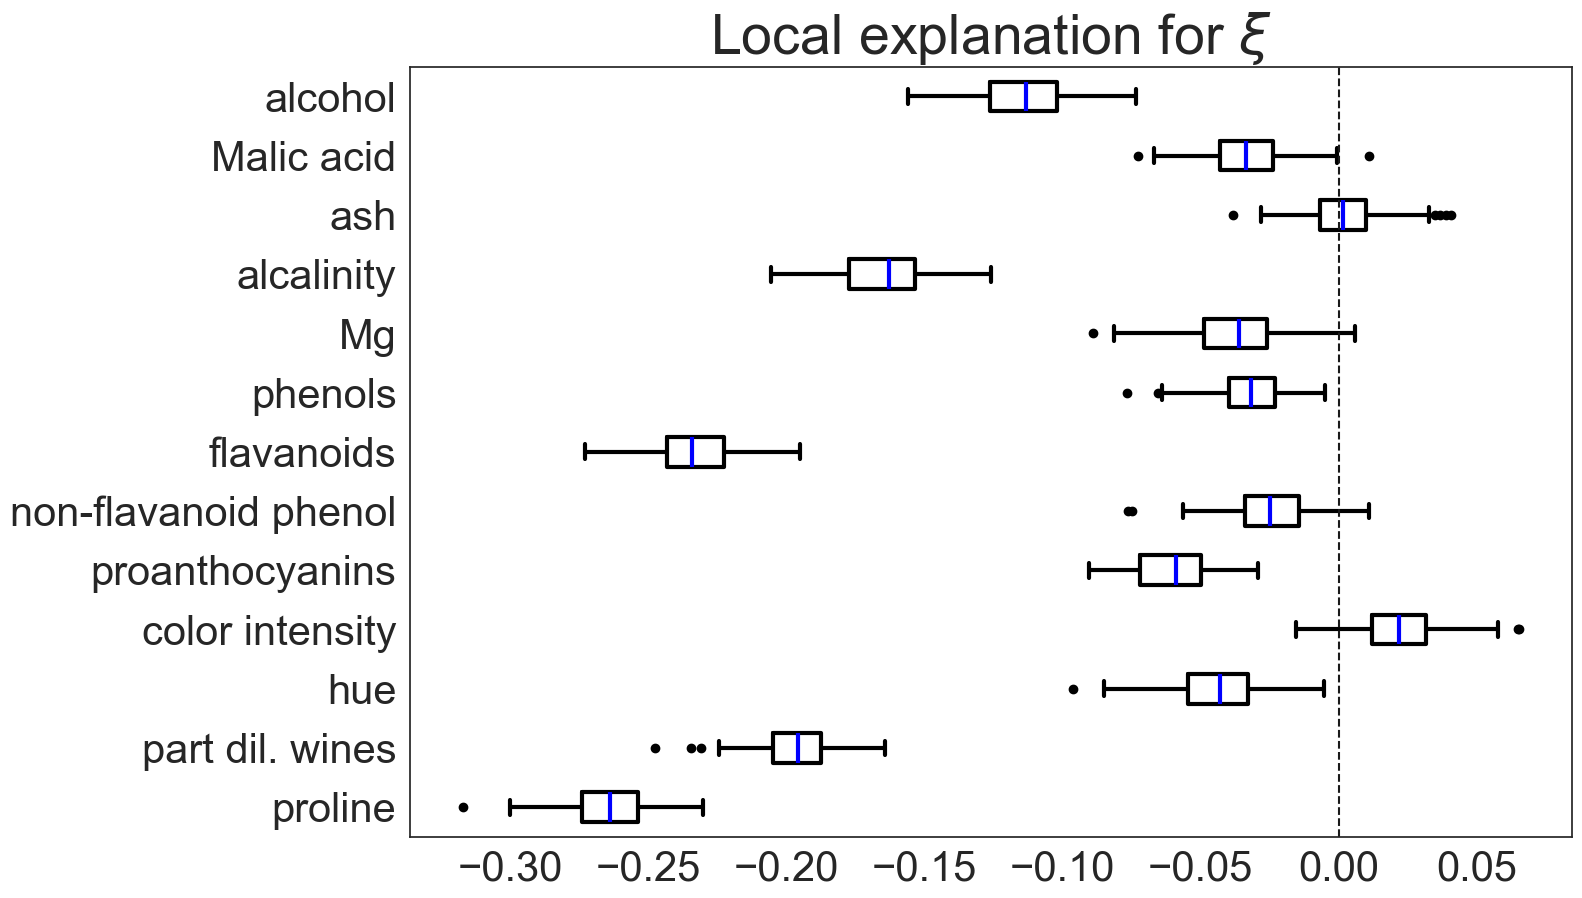

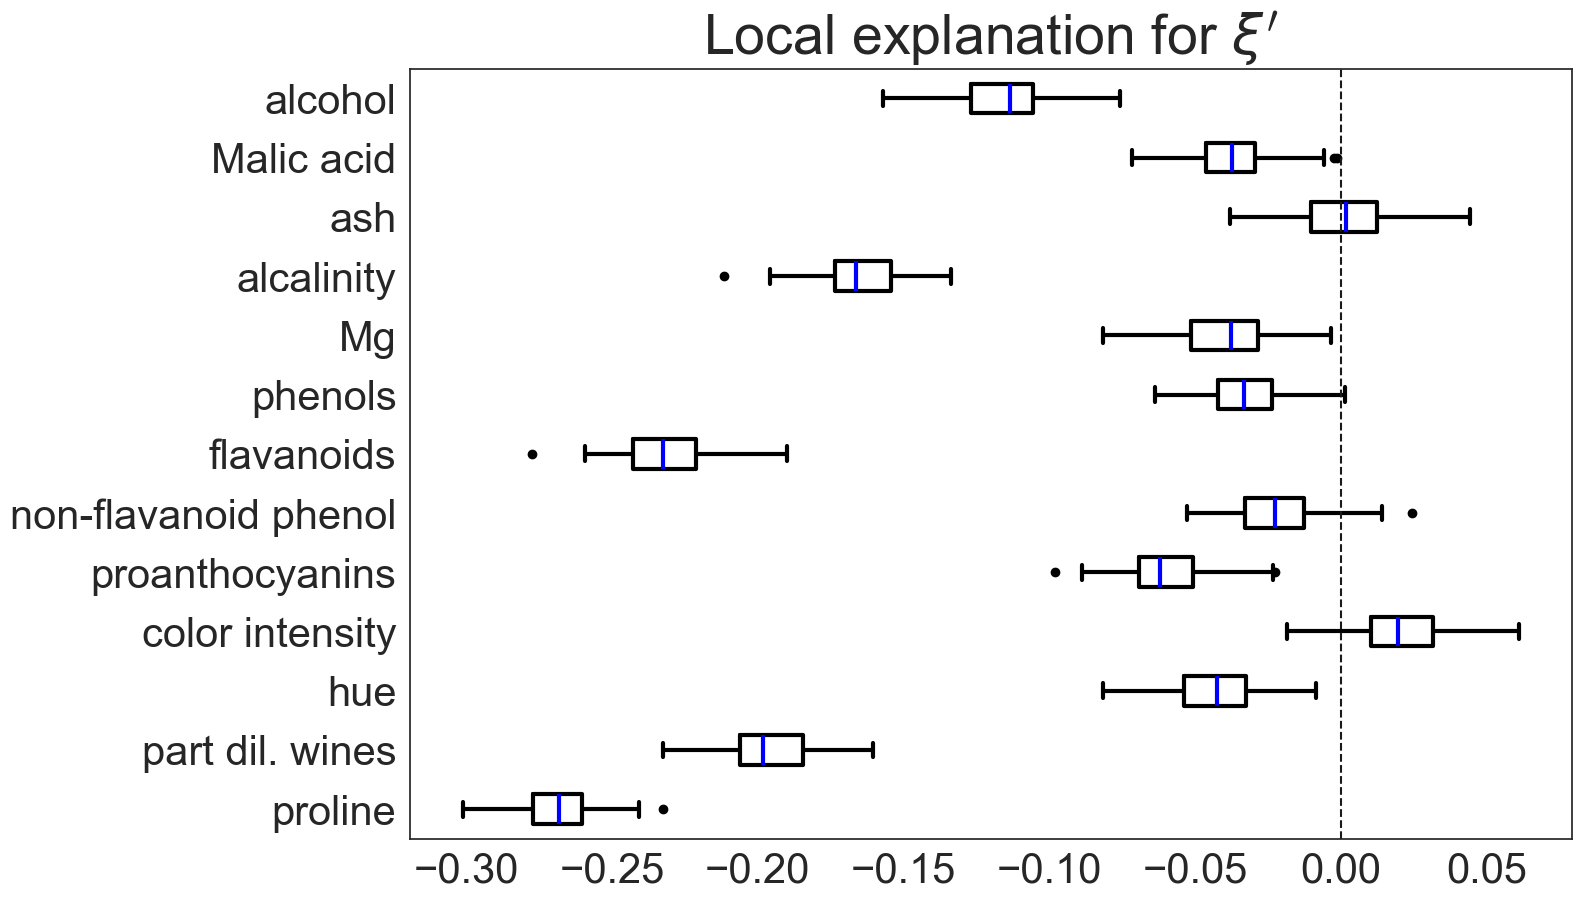

In [3]:
# -*- coding: utf-8 -*-
"""

@author: dgarreau

Explanations only depend on the bin. In this experiment, we sample points in
the same d-dimensional bin and compare the explanations given by LIME. This
script produces Figure 6 in the paper.

"""


import numpy as np
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process.kernels import RBF

# Assuming these utility functions are in the specified paths
from utils.aux_functions import get_training_data_stats
from utils.plot_functions import plot_whisker_boxes

from theory.general import get_bxi

if __name__ == "__main__":

    # number of experiments
    n_exp = 100

    # number of perturbed samples
    n_samples = 1000

    # for reproducibility
    np.random.seed(1)

    # loading data
    wine = load_wine()
    X_orig = wine['data']
    Y = wine['target']

    # scaling the data
    X_scaled = preprocessing.scale(X_orig)

    # train test split
    X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size = 0.2, random_state=5)

    # let us train a kernel regressor
    kernel = RBF(length_scale=10)
    krr_model = KernelRidge(kernel=kernel,alpha=1)
    krr_model.fit(X_train,Y_train)
    def my_model(array):
        return krr_model.predict(array)

    # dimension of the ambient space
    dim = X_scaled.shape[1]

    # the example to explain
    xi = X_scaled[0,:]

    my_features = ['alcohol','Malic acid','ash','alcalinity','Mg',
                       'phenols','flavanoids','non-flavanoid phenol',
                       'proanthocyanins','color intensity','hue',
                       'part dil. wines','proline']

    # bandwidth parameter
    nu = 5

    # number of bins along each dimension
    p = 4

    # getting the summary statistics
    my_stats = get_training_data_stats(X_scaled,p)

    # creating the explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(X_scaled,
                                                       mode='regression',
                                                       feature_names=my_features,
                                                       feature_selection='none',
                                                       training_data_stats=my_stats,
                                                       kernel_width=nu)

    # getting the bins indices of xi
    bxi = get_bxi(xi,my_stats)

    # sampling a second exmaple \xi' into to the same bin
    xi_prime = np.zeros((dim,))
    for j in range(dim):
        left = my_stats["mins"][j][bxi[j]]
        right = my_stats["maxs"][j][bxi[j]]
        xi_prime[j] = np.random.uniform(left,right)

    # getting explanations for xi
    beta_emp_store = np.zeros((n_exp,dim))
    beta_emp_store_prime = np.zeros((n_exp,dim))

    for i_exp in range(n_exp):

        if np.mod(i_exp + 1,10) == 0:
            s_exp = "Experiment {} / {} is running...".format(i_exp + 1,n_exp)
            print(s_exp)

        # Get explanation for xi
        exp_xi = explainer.explain_instance(xi,
                                            my_model,
                                            num_samples=n_samples,
                                            num_features=dim)

        # For regression, the explanation map is keyed by 1
        list_exp_xi = exp_xi.as_map()[1]
        for feature_idx, weight in list_exp_xi:
            beta_emp_store[i_exp, feature_idx] = weight

        # Get explanation for xi'
        exp_xi_prime = explainer.explain_instance(xi_prime,
                                                  my_model,
                                                  num_samples=n_samples,
                                                  num_features=dim)

        # For regression, the explanation map is keyed by 1
        list_exp_xi_prime = exp_xi_prime.as_map()[1]
        for feature_idx, weight in list_exp_xi_prime:
            beta_emp_store_prime[i_exp, feature_idx] = weight


    ###########################################################################
    # plotting the results

    # Make sure the 'results' directory exists
    if not os.path.exists('results'):
        os.makedirs('results')

    fig, ax = plt.subplots(figsize=(15,10))
    plot_whisker_boxes(beta_emp_store,
                       ax,
                       title=r"Local explanation for $\xi$",
                       rotate=True,
                       feature_names=my_features)

    s_name = str(out_path("explanations_bin_1"))
    fig.savefig(s_name + '.pdf',format='pdf',bbox_inches = 'tight',pad_inches = 0)

    fig1, ax1 = plt.subplots(figsize=(15,10))
    plot_whisker_boxes(beta_emp_store_prime,
                       ax1,
                       title=r"Local explanation for $\xi'$",
                       rotate=True,
                       feature_names=my_features)

    s_name = str(out_path("explanations_bin_2"))
    fig1.savefig(s_name + '.pdf',format='pdf',bbox_inches = 'tight',pad_inches = 0)

## Linearity of Explanations

Traceback (most recent call last):
  File "/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/gradio/blocks.py", line 2220, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/gradio/blocks.py", line 1731, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/juliawenkmann/miniconda3/envs/ml/lib/py

Experiment 10 / 100 is running...
Experiment 20 / 100 is running...
Experiment 30 / 100 is running...
Experiment 40 / 100 is running...
Experiment 50 / 100 is running...
Experiment 60 / 100 is running...
Experiment 70 / 100 is running...
Experiment 80 / 100 is running...
Experiment 90 / 100 is running...
Experiment 100 / 100 is running...


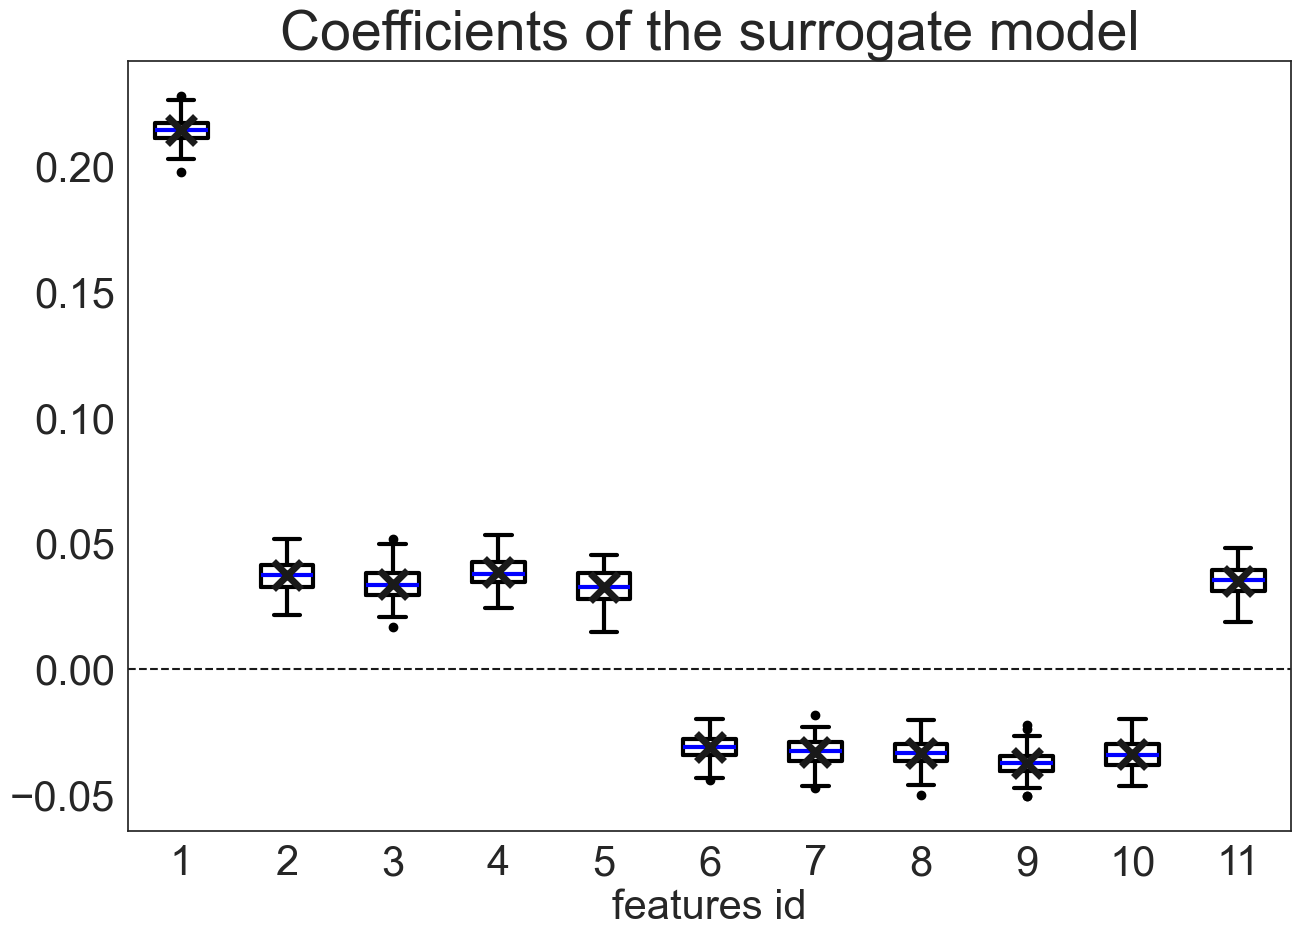

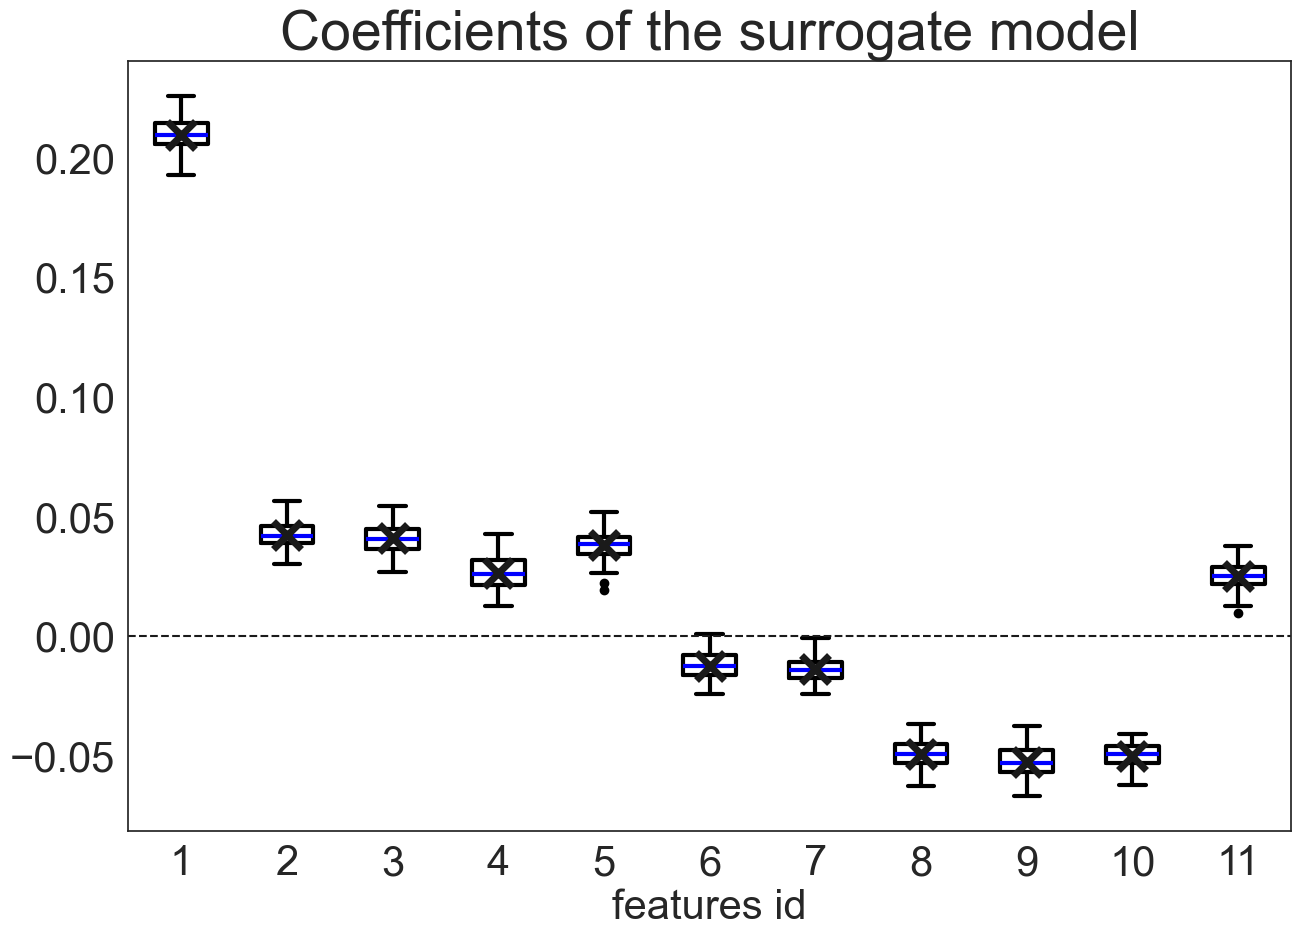

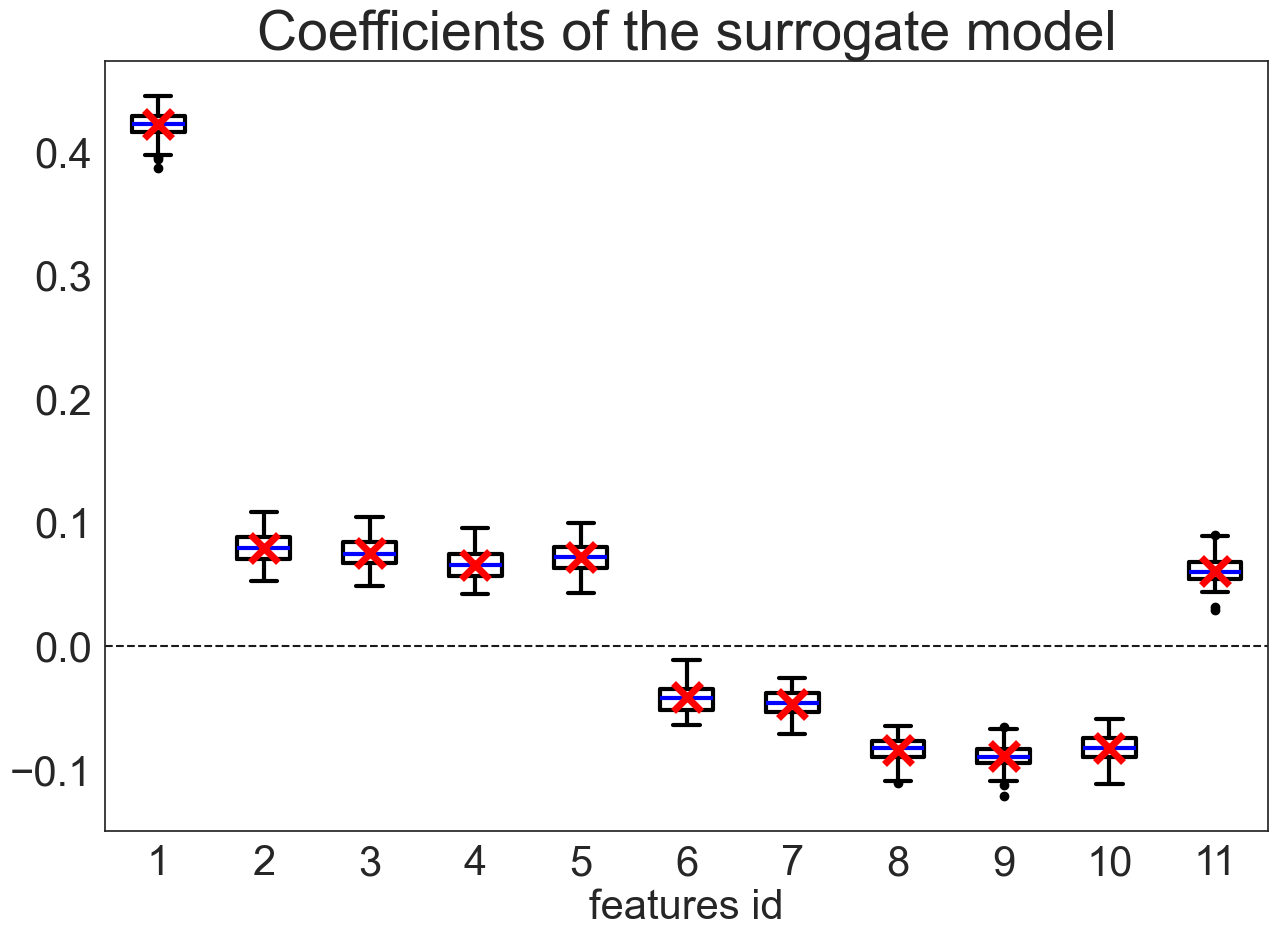

In [5]:
# -*- coding: utf-8 -*-
"""

@author: dgarreau

Demonstrating linearity of Tabular LIME explanations. We produce explanations 
for two different models as well as their sum for a given example xi. This 
script produces Figure 5 in the paper. 
 
"""

import numpy as np
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

from utils.plot_functions import plot_whisker_boxes
from utils.aux_functions import get_training_data_stats,format_coefs

if __name__ == "__main__":
    
    # for reproducibility
    np.random.seed(3)
    
    # number of experiments
    n_exp = 100
    
    # number of perturbed samples
    n_samples = 1000

    # dimension of the ambient space
    dim = 10

    # two kernel functions
    zeta_1 = np.zeros((dim,))
    zeta_2 = np.ones((dim,))
    gamma_1 = 10
    gamma_2 = gamma_1
    def my_model_1(array):
        return np.exp(-np.sum(np.square(array-zeta_1),1)/(2*gamma_1**2))
    def my_model_2(array):
        return np.exp(-np.sum(np.square(array-zeta_2),1)/(2*gamma_2**2))
    def model_sum(array):
        return my_model_1(array) + my_model_2(array)

    # the example to explain
    xi = np.random.uniform(-10,10,(dim,))

    # training set: uniform on [-10,10]^dim
    n_train = 1000
    train_set = np.random.uniform(-10,10,(n_train,dim))

    # bandwidth parameter
    nu = 10
    
    # number of bins
    p = 4

    # creating the discretizer
    my_stats = get_training_data_stats(train_set,p)

    # creating the explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(train_set, 
                                                       mode='regression',
                                                       feature_selection='none',
                                                       training_data_stats=my_stats,
                                                       kernel_width=nu)

    beta_emp_store_1   = np.zeros((n_exp,dim+1))
    beta_emp_store_2   = np.zeros((n_exp,dim+1))
    beta_emp_store_sum = np.zeros((n_exp,dim+1))
    for i_exp in range(n_exp):
        
        if np.mod(i_exp + 1,10) == 0:
            s_exp = "Experiment {} / {} is running...".format(i_exp + 1,n_exp)
            print(s_exp)
                
        # getting the explanations for both models and the sum
        exp_1 = explainer.explain_instance(xi, 
                                         my_model_1, 
                                         num_samples=n_samples)
        exp_2 = explainer.explain_instance(xi, 
                                         my_model_2, 
                                         num_samples=n_samples)
        exp_sum = explainer.explain_instance(xi, 
                                         model_sum, 
                                         num_samples=n_samples)

        # getting the coefficients of the local models
        beta_emp_store_1[i_exp,:]   = format_coefs(exp_1)
        beta_emp_store_2[i_exp,:]   = format_coefs(exp_2)
        beta_emp_store_sum[i_exp,:] = format_coefs(exp_sum)

        beta_mean_1   = np.mean(beta_emp_store_1,0)
        beta_mean_2   = np.mean(beta_emp_store_2,0)
        beta_mean_sum = np.mean(beta_emp_store_sum,0)
 

    ###########################################################################
        
    # plotting the interpretable coefficients for the three models
    fig_1, ax_1 = plt.subplots(figsize=(15,10))
    plot_whisker_boxes(beta_emp_store_1,ax_1,theo=beta_mean_1,color="k")
        
    fig_2, ax_2 = plt.subplots(figsize=(15,10))
    plot_whisker_boxes(beta_emp_store_2,ax_2,theo=beta_mean_2,color="k")
        
    fig_sum, ax_sum = plt.subplots(figsize=(15,10))
    plot_whisker_boxes(beta_emp_store_sum,ax_sum,theo=beta_mean_sum,color="red")
        
    # saving the fig
    fig_1.savefig(out_path("linearity_of_explanations_1.pdf"),format='pdf',bbox_inches = 'tight',pad_inches = 0) 
    fig_2.savefig(out_path("linearity_of_explanations_2.pdf"),format='pdf',bbox_inches = 'tight',pad_inches = 0) 
    fig_sum.savefig(out_path("linearity_of_explanations_sum.pdf"),format='pdf',bbox_inches = 'tight',pad_inches = 0) 


## Bandwidth Dependency

In [ ]:
# -*- coding: utf-8 -*-
"""

@author: dgarreau

In this experiments, we look into the behavior of interpretable coefficients 
when the bandwidth parameter varies. The model is a kernel regressor trained 
on the Wine dataset. This script produces Figure 7 in the paper.

"""

import numpy as np
import matplotlib.pyplot as plt

import lime
import lime.lime_tabular

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process.kernels import RBF

from utils.aux_functions import format_coefs,get_training_data_stats

if __name__ == "__main__":
    
    # number of experiments
    n_exp = 100
    
    # number of perturbed samples
    n_samples = 1000
    
    # number of bins along each dimension
    p = 4
    
    # for reproducibility
    np.random.seed(1)

    # bandwidth parameter for the RBF kernel
    gamma = 5
    
    # get the data and train a kernel ridge regressor
    wine = load_wine()
    X_orig = wine['data']
    Y = wine['target']
    X_scaled = preprocessing.scale(X_orig)
    X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size = 0.2, random_state=5)
    kernel = RBF(length_scale=gamma)
    krr_model = KernelRidge(kernel=kernel,alpha=1)
    krr_model.fit(X_train,Y_train)

    # the model to explain is the kernel ridge regressor we just trained
    def my_model(array):
        return krr_model.predict(array)    
    
    # dimension of the ambient space
    dim = X_scaled.shape[1]

    # the example to explain
    xi = X_scaled[0,:]

    # grid of bandwidths
    n_nu    = 50
    nu_min  = 0.001
    nu_max  = 4
    nu_grid = np.linspace(nu_min,nu_max,num=n_nu)
    
    # get the summary of the training data
    my_stats = get_training_data_stats(X_scaled,p)

    coef_store = np.zeros((n_nu,dim+1))
    std_store = np.zeros((n_nu,dim+1))
    beta_emp_store = np.zeros((n_nu,n_exp,dim+1))
    
    # main loop: for each bandwidth obtain many LIME explanations
    for i_nu in range(n_nu):
        
        nu = nu_grid[i_nu]
        s_nu = "bandwidth: {}".format(nu)
        print(s_nu)

        # creating the explainer
        explainer = lime.lime_tabular.LimeTabularExplainer(X_orig, 
                                                           mode='regression',
                                                           feature_selection='none',
                                                           training_data_stats=my_stats,
                                                           kernel_width=nu)
        
        for i_exp in range(n_exp):
            
            if np.mod(i_exp + 1,10) == 0:
                s_exp = "Experiment {} / {} is running...".format(i_exp + 1,n_exp)
                print(s_exp)
            
            # getting the explanation
            exp = explainer.explain_instance(xi, 
                                             my_model, 
                                             num_samples=n_samples)

            # getting the coefficients of the local model
            beta_emp_store[i_nu,i_exp,:] = format_coefs(exp)

        coef_store[i_nu] = np.mean(beta_emp_store[i_nu,:,:],axis=0)
        std_store[i_nu] = np.std(beta_emp_store[i_nu,:,:],axis=0)


    # default choice of bandwidth
    default_nu = np.sqrt(0.75*dim)

    ###########################################################################

    small_fs = 30
    big_fs = 40
    lw = 3
    ms = 6
        
    for index in range(dim):
        
        plt.rc('xtick',labelsize=small_fs)
        plt.rc('ytick',labelsize=small_fs) 
        fig, ax = plt.subplots(figsize=(15,10))
        s_title = "Coefficient {} as a function of the bandwidth".format(index+1)
        ax.set_title(s_title,fontsize=big_fs)
        ax.plot(nu_grid,coef_store[:,index+1],color='k',linewidth=lw,zorder=5)
        
        # shadede area is standard deviation over the experiments
        ax.fill_between(nu_grid,coef_store[:,index+1]-std_store[:,index+1],coef_store[:,index+1]+std_store[:,index+1],color='b',alpha=0.5)
        ax.axhline(y=0,c='k',linestyle='--')
        ax.axvline(x=default_nu,c='r',linewidth=lw)
        ax.set_xlabel("bandwidth",fontsize=small_fs)
        
        # saving the figure
        s_name = str(out_path("coef_vs_bandwidth_wine_krr_{}".format(index)))
        fig.savefig(s_name + '.pdf',format='pdf',bbox_inches = 'tight',pad_inches = 0) 


        




bandwidth: 0.001
Experiment 10 / 100 is running...
Experiment 20 / 100 is running...
Experiment 30 / 100 is running...
Experiment 40 / 100 is running...
Experiment 50 / 100 is running...
Experiment 60 / 100 is running...
Experiment 70 / 100 is running...
Experiment 80 / 100 is running...
Experiment 90 / 100 is running...
Experiment 100 / 100 is running...
bandwidth: 0.08261224489795918
Experiment 10 / 100 is running...
Experiment 20 / 100 is running...
Experiment 30 / 100 is running...
Experiment 40 / 100 is running...
Experiment 50 / 100 is running...
Experiment 60 / 100 is running...
Experiment 70 / 100 is running...
Experiment 80 / 100 is running...
Experiment 90 / 100 is running...
Experiment 100 / 100 is running...
bandwidth: 0.16422448979591836
Experiment 10 / 100 is running...
Experiment 20 / 100 is running...
Experiment 30 / 100 is running...
Experiment 40 / 100 is running...
Experiment 50 / 100 is running...
Experiment 60 / 100 is running...
Experiment 70 / 100 is running...
E